In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
climate_data = pd.read_csv('../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_med'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

print('Environmental Data Summary (Manaus, Brazil 2016-2024)')
print('='*60)
print(f"Temperature:  min={temp_actual.min():.1f}°C, max={temp_actual.max():.1f}°C, mean={temp_actual.mean():.1f}°C")
print(f"Humidity:     min={humid_actual.min():.1f}%, max={humid_actual.max():.1f}%, mean={humid_actual.mean():.1f}%")
print(f"Precipitation: min={rain_actual.min():.1f}mm, max={rain_actual.max():.1f}mm, mean={rain_actual.mean():.1f}mm")
print(f"Fire counts:  min={fire_actual.min():.0f}, max={fire_actual.max():.0f}, mean={fire_actual.mean():.1f}")
print(f"Deforestation: min={defor_actual.min():.2f}km², max={defor_actual.max():.2f}km², mean={defor_actual.mean():.2f}km²")
print('='*60)


Environmental Data Summary (Manaus, Brazil 2016-2024)
Temperature:  min=23.1°C, max=32.5°C, mean=26.7°C
Humidity:     min=46.6%, max=95.9%, mean=83.3%
Precipitation: min=0.0mm, max=71.2mm, mean=3.7mm
Fire counts:  min=0, max=169, mean=0.9
Deforestation: min=0.00km², max=8.34km², mean=0.02km²


In [3]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================
T_prime = 25.6
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 4.0
A = 12.5
B = 15.0
C = -48.78
DD = 105
Tmin = 14.5
R_L = 32.67

defor_max_effect = 0.30
defor_scale = 0.0001
fire_smoke_effect = 0.40
fire_habitat_effect = 0.20


In [4]:
# ============================================================================
# MOSQUITO LIFE CYCLE FUNCTIONS
# ============================================================================

def tau_L(Temp):
    denom = c1 * Temp + c2
    if denom <= 0:
        return 100
    return 1 / denom

def p_T(Temp, Umid):
    denom = A * Temp**2 + B * Temp + C
    if denom >= 0:
        p_T_temp = 0.85
    else:
        p_T_temp = np.exp(-1 / denom)
    
    if Umid < 50:
        p_U = 0.0
    elif Umid < 60:
        p_U = (Umid - 50) / 10
    else:
        p_U = 1.0
    
    return p_T_temp * p_U

def p_LT(Temp):
    exponent = c1 * Temp + c2
    if exponent > 10:
        return 0
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

def p_ER(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

def p_PR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

def tau_M(Temp):
    if Temp <= Tmin:
        return 50
    return DD / (Temp - Tmin)

def mu(Temp, Umid):
    p_T_val = p_T(Temp, Umid)
    if p_T_val <= 0:
        return 0.15
    mu_val = -np.log(p_T_val)
    return min(mu_val, 0.3)

def a(Temp):
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return np.minimum(a_val, 0.8)

def a_with_fire(Temp, fire_counts, fire_smoke_effect):
    base_rate = a(Temp)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    smoke_reduction = fire_smoke_effect * fire_intensity
    return base_rate * (1 - smoke_reduction)

def b_rate(Rain, Temp, R_L):
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0:
        return 0
    numerator = B_E * p_ER(Rain, R_L) * p_LR(Rain, R_L) * p_LT(Temp) * p_PR(Rain, R_L)
    denominator = tau_E + tau_L_curr + tau_P
    if denominator <= 0:
        return 0
    return numerator / denominator

def b_rate_with_environment(Rain, Temp, R_L, fire_counts, total_degradation):
    base_rate = b_rate(Rain, Temp, R_L)
    defor_effect = min(total_degradation * defor_scale, defor_max_effect)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_habitat_destruction = fire_habitat_effect * fire_intensity
    net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
    return base_rate * net_effect

def mu_with_fire(Temp, Umid, fire_counts, fire_habitat_effect):
    base_mu = mu(Temp, Umid)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_mortality_increase = 0.15 * fire_intensity
    return min(base_mu + fire_mortality_increase, 0.5)

print('Functions loaded successfully!')


Functions loaded successfully!


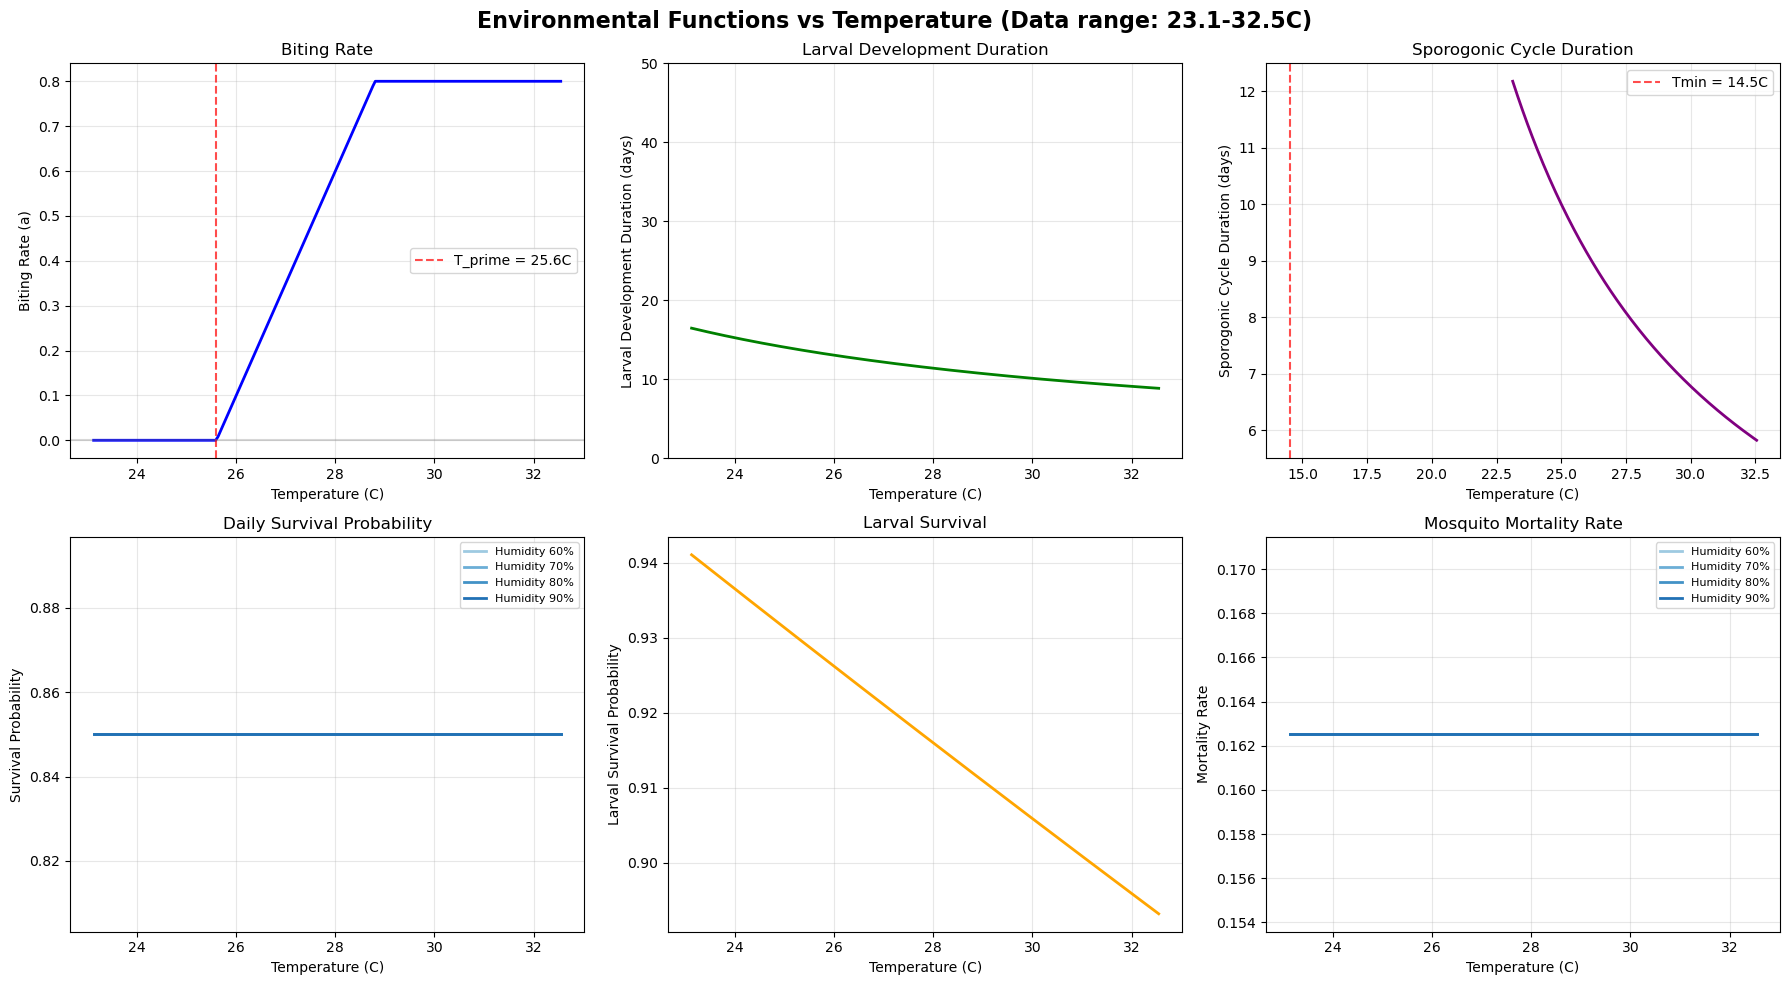

In [5]:
# ============================================================================
# PLOT 1: FUNCTIONS VS TEMPERATURE (using actual data range)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Environmental Functions vs Temperature (Data range: {temp_actual.min():.1f}-{temp_actual.max():.1f}C)', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 200)
rain_fixed = rain_actual.mean()
humid_fixed = humid_actual.mean()

# 1. Biting rate a(Temp)
ax = axes[0, 0]
ax.plot(temp_range, [a(T) for T in temp_range], 'b-', linewidth=2)
ax.axvline(x=T_prime, color='r', linestyle='--', alpha=0.7, label=f'T_prime = {T_prime}C')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Larval development duration tau_L(Temp)
ax = axes[0, 1]
ax.plot(temp_range, [tau_L(T) for T in temp_range], 'g-', linewidth=2)
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Larval Development Duration (days)')
ax.set_title('Larval Development Duration')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50)

# 3. Sporogonic cycle duration tau_M(Temp)
ax = axes[0, 2]
ax.plot(temp_range, [tau_M(T) for T in temp_range], 'purple', linewidth=2)
ax.axvline(x=Tmin, color='r', linestyle='--', alpha=0.7, label=f'Tmin = {Tmin}C')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Sporogonic Cycle Duration (days)')
ax.set_title('Sporogonic Cycle Duration')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Survival probability p_T(Temp, humidity)
ax = axes[1, 0]
humidities = [60, 70, 80, 90]
colors = ['#9ecae1', '#6baed6', '#4292c6', '#2171b5']
for hum, color in zip(humidities, colors):
    ax.plot(temp_range, [p_T(T, hum) for T in temp_range], color=color, linewidth=2, label=f'Humidity {hum}%')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Survival Probability')
ax.set_title('Daily Survival Probability')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Larval survival p_LT(Temp)
ax = axes[1, 1]
ax.plot(temp_range, [p_LT(T) for T in temp_range], 'orange', linewidth=2)
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Larval Survival Probability')
ax.set_title('Larval Survival')
ax.grid(True, alpha=0.3)

# 6. Mortality rate mu(Temp, humidity)
ax = axes[1, 2]
for hum, color in zip(humidities, colors):
    ax.plot(temp_range, [mu(T, hum) for T in temp_range], color=color, linewidth=2, label=f'Humidity {hum}%')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mosquito Mortality Rate')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


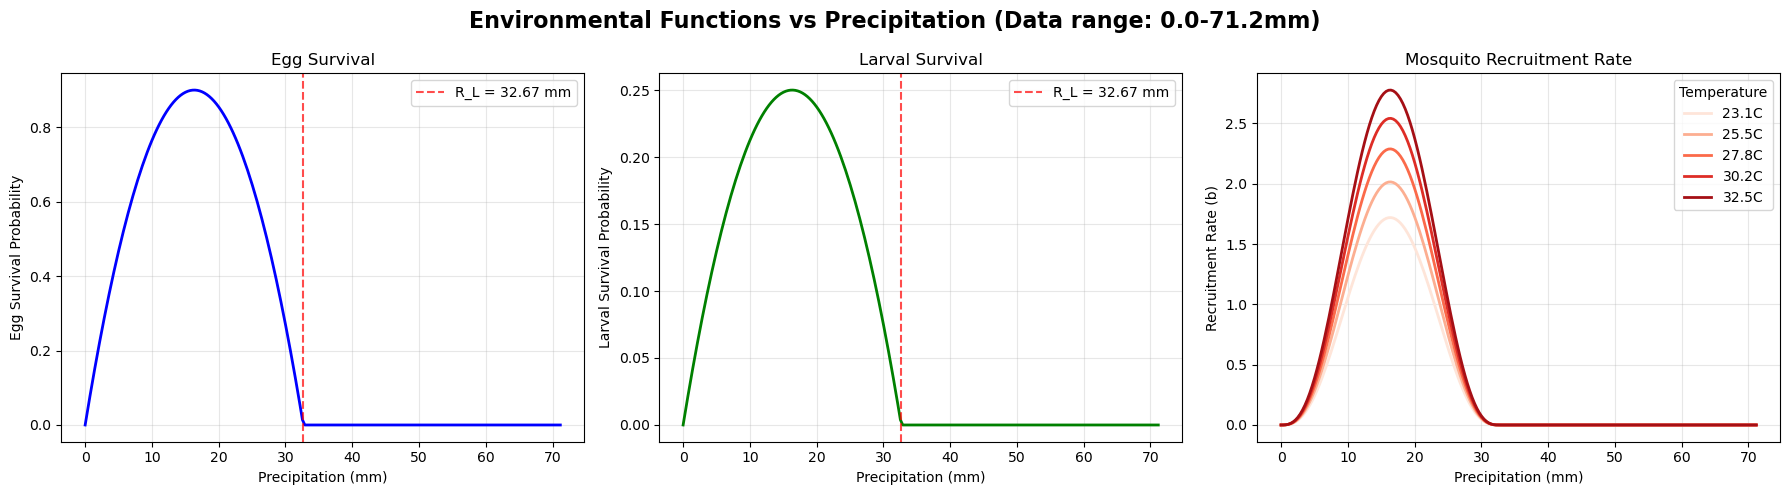

In [6]:
# ============================================================================
# PLOT 2: FUNCTIONS VS PRECIPITATION (using actual data range)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Environmental Functions vs Precipitation (Data range: {rain_actual.min():.1f}-{rain_actual.max():.1f}mm)', fontsize=16, fontweight='bold')

rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 200)
temp_fixed = temp_actual.mean()

# 1. Egg survival p_ER(Rain)
ax = axes[0]
ax.plot(rain_range, [p_ER(R, R_L) for R in rain_range], 'b-', linewidth=2)
ax.axvline(x=R_L, color='r', linestyle='--', alpha=0.7, label=f'R_L = {R_L} mm')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Egg Survival Probability')
ax.set_title('Egg Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Larval survival p_LR(Rain)
ax = axes[1]
ax.plot(rain_range, [p_LR(R, R_L) for R in rain_range], 'g-', linewidth=2)
ax.axvline(x=R_L, color='r', linestyle='--', alpha=0.7, label=f'R_L = {R_L} mm')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Larval Survival Probability')
ax.set_title('Larval Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Recruitment rate b_rate(Rain, Temp)
ax = axes[2]
temps = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 4 for i in range(5)]
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
for temp, color in zip(temps, colors):
    ax.plot(rain_range, [b_rate(R, temp, R_L) for R in rain_range], color=color, linewidth=2, label=f'{temp:.1f}C')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title('Mosquito Recruitment Rate')
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


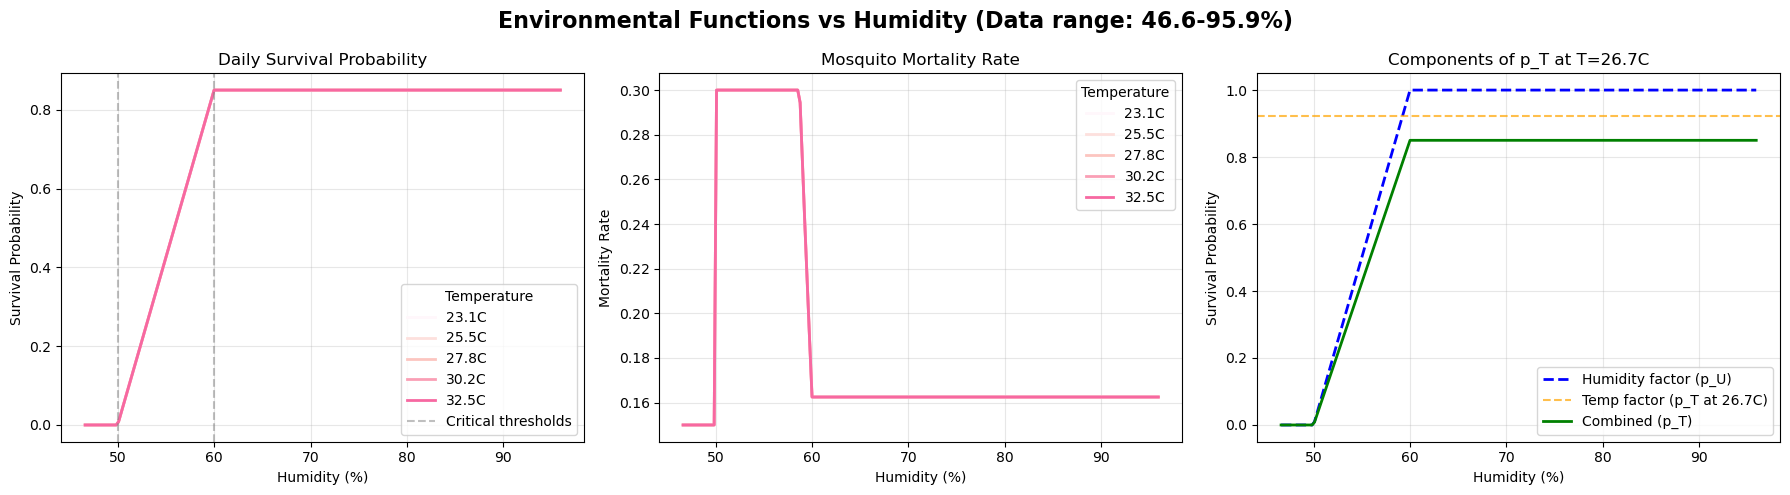

In [7]:
# ============================================================================
# PLOT 3: FUNCTIONS VS HUMIDITY (using actual data range)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Environmental Functions vs Humidity (Data range: {humid_actual.min():.1f}-{humid_actual.max():.1f}%)', fontsize=16, fontweight='bold')

humid_range = np.linspace(max(0, humid_actual.min()), min(100, humid_actual.max()), 200)
temp_fixed = temp_actual.mean()

# 1. Survival probability
ax = axes[0]
temperatures = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 4 for i in range(5)]
colors = ['#fff7fb', '#fde0dd', '#fcc5c0', '#fa9fb5', '#f768a1']
for temp, color in zip(temperatures, colors):
    ax.plot(humid_range, [p_T(temp, h) for h in humid_range], color=color, linewidth=2, label=f'{temp:.1f}C')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=60, color='gray', linestyle='--', alpha=0.5, label='Critical thresholds')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Survival Probability')
ax.set_title('Daily Survival Probability')
ax.legend(title='Temperature', loc='lower right')
ax.grid(True, alpha=0.3)

# 2. Mortality rate
ax = axes[1]
for temp, color in zip(temperatures, colors):
    ax.plot(humid_range, [mu(temp, h) for h in humid_range], color=color, linewidth=2, label=f'{temp:.1f}C')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mosquito Mortality Rate')
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

# 3. Combined survival components
ax = axes[2]
p_T_temp_only = [np.exp(-(c1 * temp_fixed + c2)) if c1 * temp_fixed + c2 < 10 else 0 for _ in humid_range]
p_U_only = [0 if h < 50 else (h - 50) / 10 if h < 60 else 1 for h in humid_range]
p_T_combined = [p_T(temp_fixed, h) for h in humid_range]
ax.plot(humid_range, p_U_only, 'b--', linewidth=2, label='Humidity factor (p_U)')
ax.axhline(y=p_T_temp_only[0], color='orange', linestyle='--', alpha=0.7, label=f'Temp factor (p_T at {temp_fixed:.1f}C)')
ax.plot(humid_range, p_T_combined, 'g-', linewidth=2, label='Combined (p_T)')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Survival Probability')
ax.set_title(f'Components of p_T at T={temp_fixed:.1f}C')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


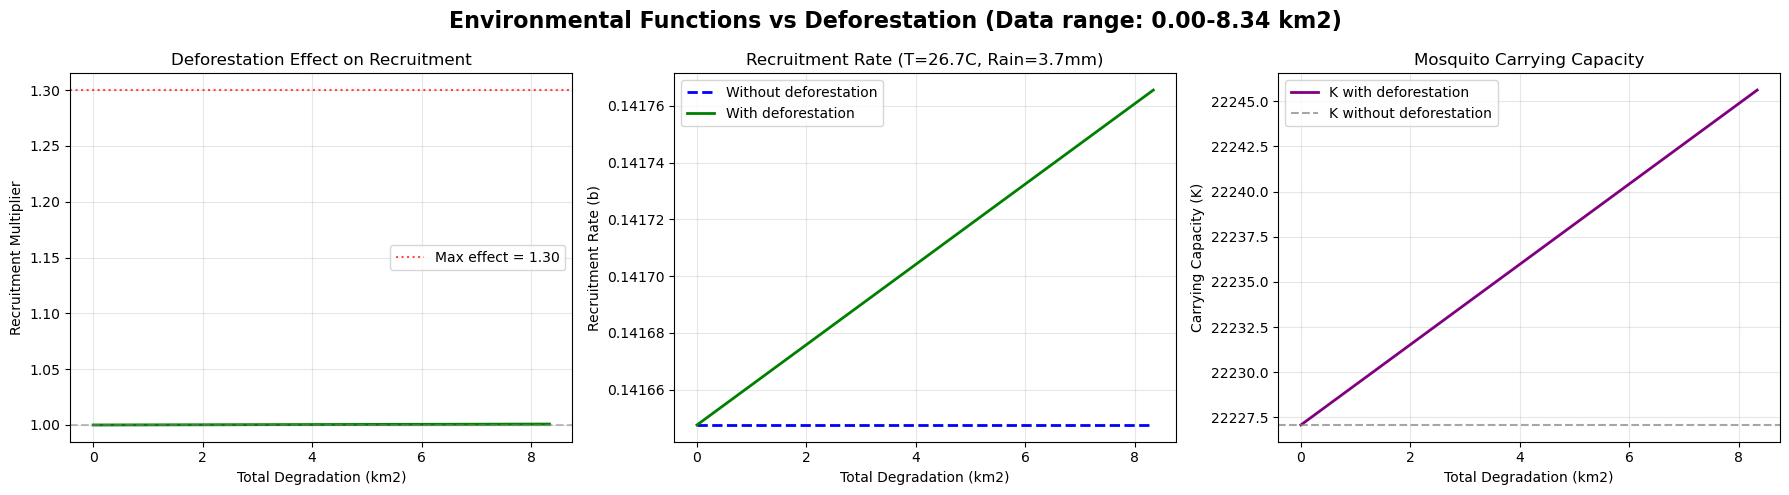

In [8]:
# ============================================================================
# PLOT 4: FUNCTIONS VS DEFORESTATION (using actual data range)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Environmental Functions vs Deforestation (Data range: {defor_actual.min():.2f}-{defor_actual.max():.2f} km2)', fontsize=16, fontweight='bold')

defor_range = np.linspace(0, min(10, defor_actual.max()), 200)
temp_fixed = temp_actual.mean()
rain_fixed = rain_actual.mean()
fire_fixed = 0

# 1. Deforestation effect on recruitment
ax = axes[0]
recruitment_effect = [1 + min(d * defor_scale, defor_max_effect) for d in defor_range]
ax.plot(defor_range, recruitment_effect, 'g-', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1 + defor_max_effect, color='r', linestyle=':', alpha=0.7, label=f'Max effect = {1 + defor_max_effect:.2f}')
ax.fill_between(defor_range, 1, recruitment_effect, alpha=0.3, color='green')
ax.set_xlabel('Total Degradation (km2)')
ax.set_ylabel('Recruitment Multiplier')
ax.set_title('Deforestation Effect on Recruitment')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Recruitment rate with deforestation
ax = axes[1]
b_no_defor = [b_rate(rain_fixed, temp_fixed, R_L) for _ in defor_range]
b_with_defor = [b_rate_with_environment(rain_fixed, temp_fixed, R_L, fire_fixed, d) for d in defor_range]
ax.plot(defor_range, b_no_defor, 'b--', linewidth=2, label='Without deforestation')
ax.plot(defor_range, b_with_defor, 'g-', linewidth=2, label='With deforestation')
ax.set_xlabel('Total Degradation (km2)')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title(f'Recruitment Rate (T={temp_fixed:.1f}C, Rain={rain_fixed:.1f}mm)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Carrying capacity effect
ax = axes[2]
base_K = 100000
temp_factor = max(0.1, min(1, (temp_fixed - 15) / 15))
rain_factor = min(1, max(0, rain_fixed / R_L))
seasonal_factor = 2.5
K_base = base_K * temp_factor * rain_factor * seasonal_factor
K_with_defor = [K_base * (1 + min(d * defor_scale, defor_max_effect)) for d in defor_range]
ax.plot(defor_range, K_with_defor, 'purple', linewidth=2, label='K with deforestation')
ax.axhline(y=K_base, color='gray', linestyle='--', alpha=0.7, label='K without deforestation')
ax.set_xlabel('Total Degradation (km2)')
ax.set_ylabel('Carrying Capacity (K)')
ax.set_title('Mosquito Carrying Capacity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


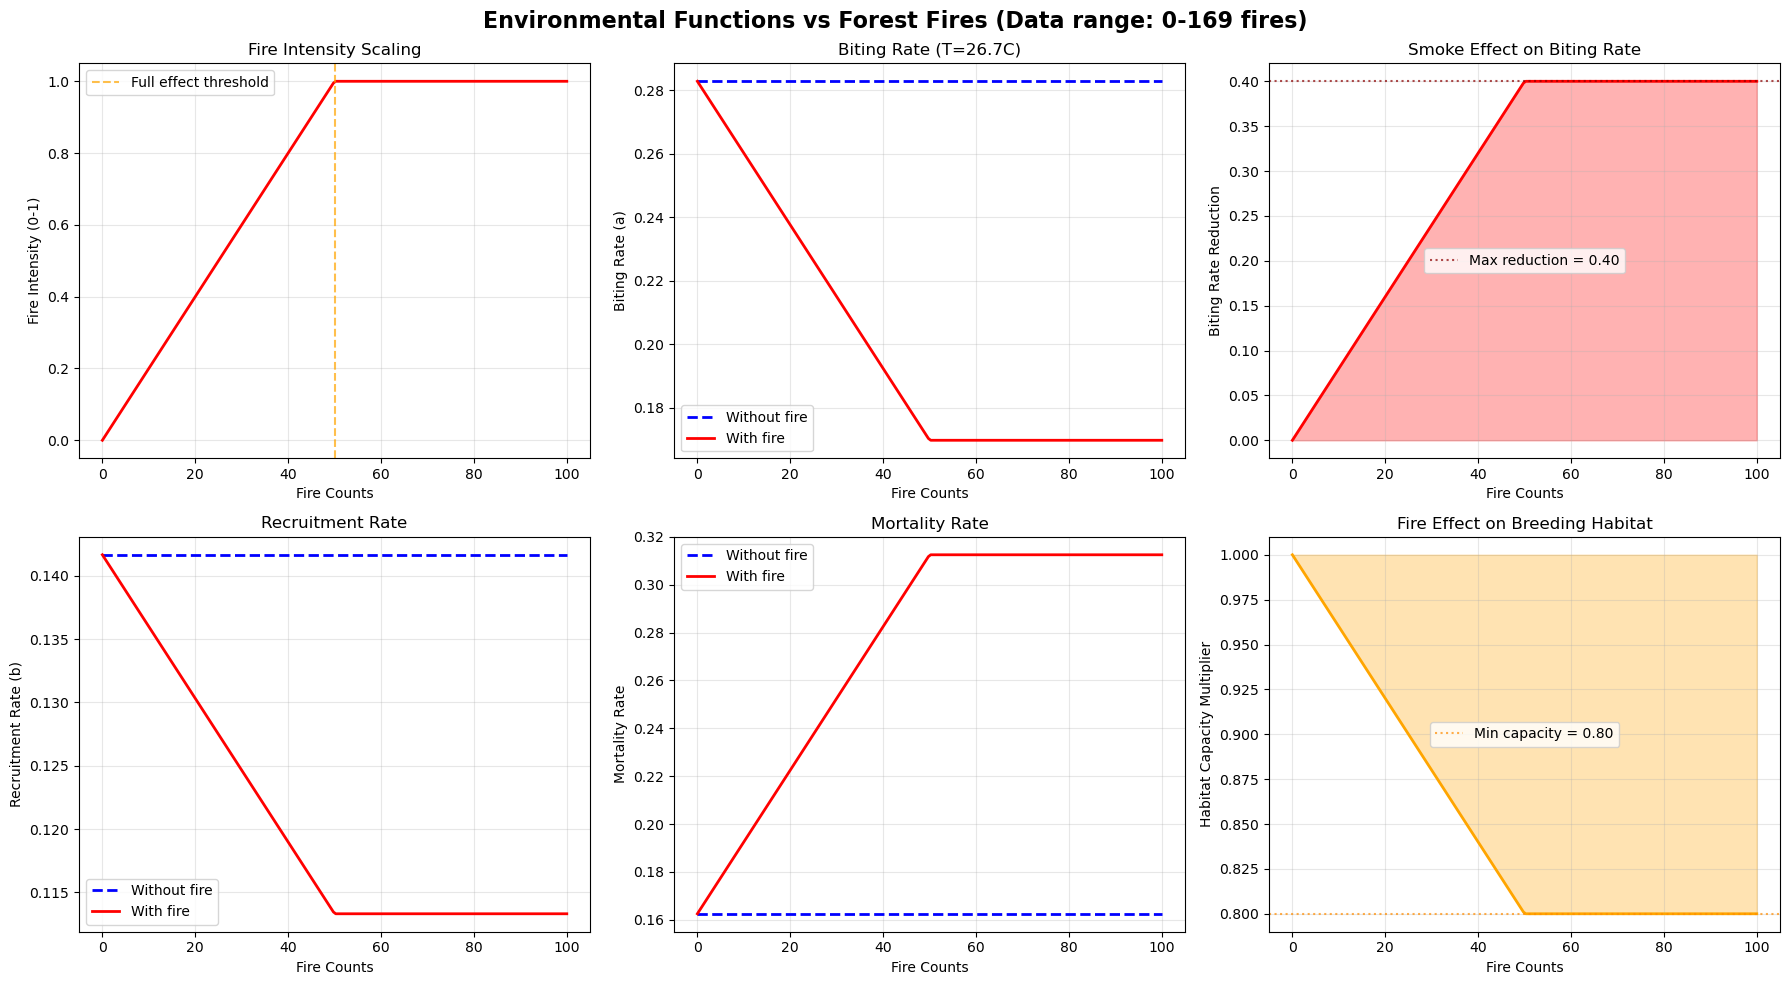

In [9]:
# ============================================================================
# PLOT 5: FUNCTIONS VS FOREST FIRES (using actual data range)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Environmental Functions vs Forest Fires (Data range: {fire_actual.min():.0f}-{fire_actual.max():.0f} fires)', fontsize=16, fontweight='bold')

fire_range = np.linspace(0, min(100, fire_actual.max()), 200)
temp_fixed = temp_actual.mean()
humid_fixed = humid_actual.mean()
rain_fixed = rain_actual.mean()
defor_fixed = 0

# 1. Fire intensity scaling
ax = axes[0, 0]
fire_intensity = [min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, fire_intensity, 'r-', linewidth=2)
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.7, label='Full effect threshold')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Fire Intensity (0-1)')
ax.set_title('Fire Intensity Scaling')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Biting rate with fire effect
ax = axes[0, 1]
a_base = [a(temp_fixed) for _ in fire_range]
a_with_fire_effect = [a_with_fire(temp_fixed, f, fire_smoke_effect) for f in fire_range]
ax.plot(fire_range, a_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, a_with_fire_effect, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Biting Rate (a)')
ax.set_title(f'Biting Rate (T={temp_fixed:.1f}C)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Biting rate reduction
ax = axes[0, 2]
reduction = [fire_smoke_effect * min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, reduction, 'r-', linewidth=2)
ax.fill_between(fire_range, 0, reduction, alpha=0.3, color='red')
ax.axhline(y=fire_smoke_effect, color='darkred', linestyle=':', alpha=0.7, label=f'Max reduction = {fire_smoke_effect:.2f}')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Biting Rate Reduction')
ax.set_title('Smoke Effect on Biting Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Recruitment rate with fire effect
ax = axes[1, 0]
b_base = [b_rate(rain_fixed, temp_fixed, R_L) for _ in fire_range]
b_with_fire = [b_rate_with_environment(rain_fixed, temp_fixed, R_L, f, defor_fixed) for f in fire_range]
ax.plot(fire_range, b_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, b_with_fire, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title('Recruitment Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Mortality rate with fire effect
ax = axes[1, 1]
mu_base = [mu(temp_fixed, humid_fixed) for _ in fire_range]
mu_with_fire_effect = [mu_with_fire(temp_fixed, humid_fixed, f, fire_habitat_effect) for f in fire_range]
ax.plot(fire_range, mu_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, mu_with_fire_effect, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mortality Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Net habitat effect
ax = axes[1, 2]
habitat_effect = [1 - fire_habitat_effect * min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, habitat_effect, 'orange', linewidth=2)
ax.fill_between(fire_range, habitat_effect, 1, alpha=0.3, color='orange')
ax.axhline(y=1 - fire_habitat_effect, color='darkorange', linestyle=':', alpha=0.7, label=f'Min capacity = {1 - fire_habitat_effect:.2f}')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Habitat Capacity Multiplier')
ax.set_title('Fire Effect on Breeding Habitat')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


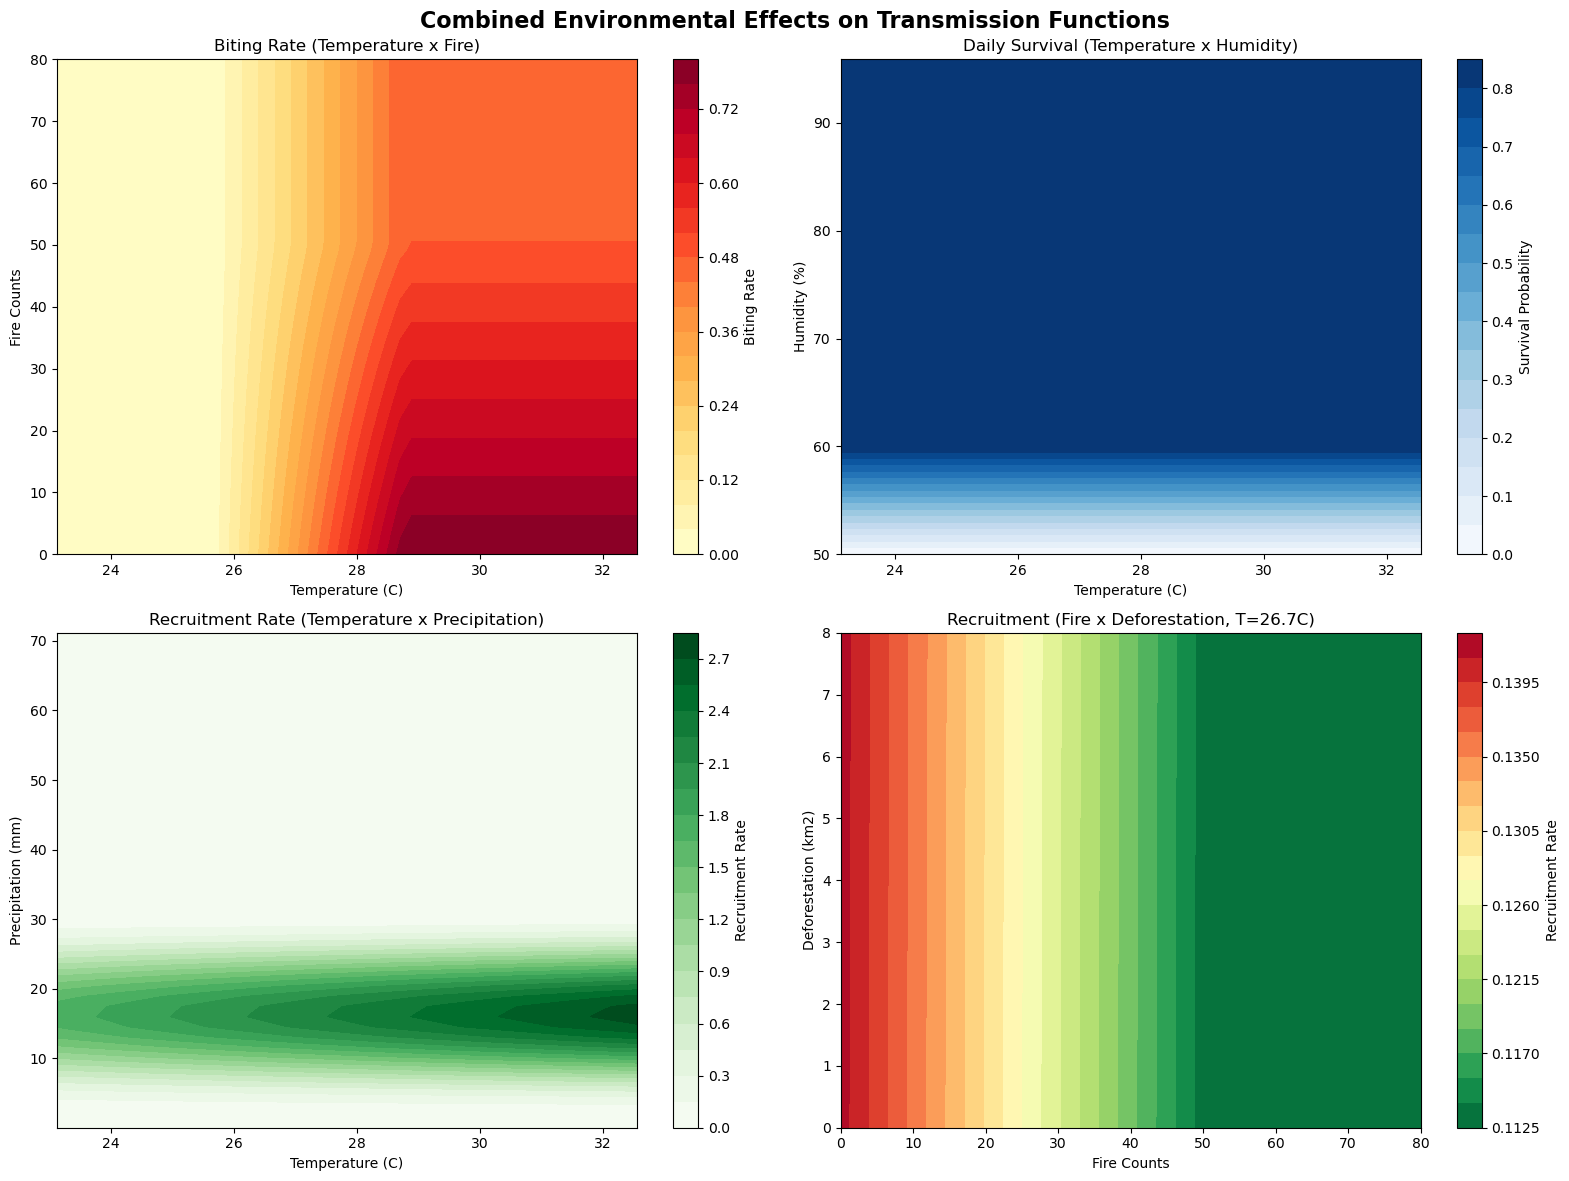

In [10]:
# ============================================================================
# PLOT 6: COMBINED ENVIRONMENTAL EFFECTS (using actual data ranges)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Combined Environmental Effects on Transmission Functions', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 50)
humid_range = np.linspace(max(50, humid_actual.min()), min(100, humid_actual.max()), 50)
rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 50)
fire_range = np.linspace(0, min(80, fire_actual.max()), 50)
defor_range = np.linspace(0, min(8, defor_actual.max()), 50)

# 1. Biting rate: Temperature and Fire combined
ax = axes[0, 0]
T_mesh = np.meshgrid(temp_range, fire_range)[0]
F_mesh = np.meshgrid(temp_range, fire_range)[1]
a_combined = np.array([[a_with_fire(T, F, fire_smoke_effect) for T in temp_range] for F in fire_range])
contour = ax.contourf(temp_range, fire_range, a_combined, levels=20, cmap='YlOrRd')
plt.colorbar(contour, ax=ax, label='Biting Rate')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Fire Counts')
ax.set_title('Biting Rate (Temperature x Fire)')

# 2. Survival: Temperature and Humidity combined
ax = axes[0, 1]
T_mesh = np.meshgrid(temp_range, humid_range)[0]
H_mesh = np.meshgrid(temp_range, humid_range)[1]
p_T_combined = np.array([[p_T(T, H) for T in temp_range] for H in humid_range])
contour = ax.contourf(temp_range, humid_range, p_T_combined, levels=20, cmap='Blues')
plt.colorbar(contour, ax=ax, label='Survival Probability')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Humidity (%)')
ax.set_title('Daily Survival (Temperature x Humidity)')

# 3. Recruitment: Temperature and Precipitation combined
ax = axes[1, 0]
T_mesh = np.meshgrid(temp_range, rain_range)[0]
R_mesh = np.meshgrid(temp_range, rain_range)[1]
b_combined = np.array([[b_rate(R, T, R_L) for T in temp_range] for R in rain_range])
contour = ax.contourf(temp_range, rain_range, b_combined, levels=20, cmap='Greens')
plt.colorbar(contour, ax=ax, label='Recruitment Rate')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Recruitment Rate (Temperature x Precipitation)')

# 4. Full recruitment with all environmental factors
ax = axes[1, 1]
temp_fixed = temp_actual.mean()
rain_fixed = rain_actual.mean()
F_mesh, D_mesh = np.meshgrid(fire_range, defor_range)
b_full = np.array([[b_rate_with_environment(rain_fixed, temp_fixed, R_L, F, D) for F in fire_range] for D in defor_range])
contour = ax.contourf(fire_range, defor_range, b_full, levels=20, cmap='RdYlGn_r')
plt.colorbar(contour, ax=ax, label='Recruitment Rate')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Deforestation (km2)')
ax.set_title(f'Recruitment (Fire x Deforestation, T={temp_fixed:.1f}C)')

plt.tight_layout()
plt.show()


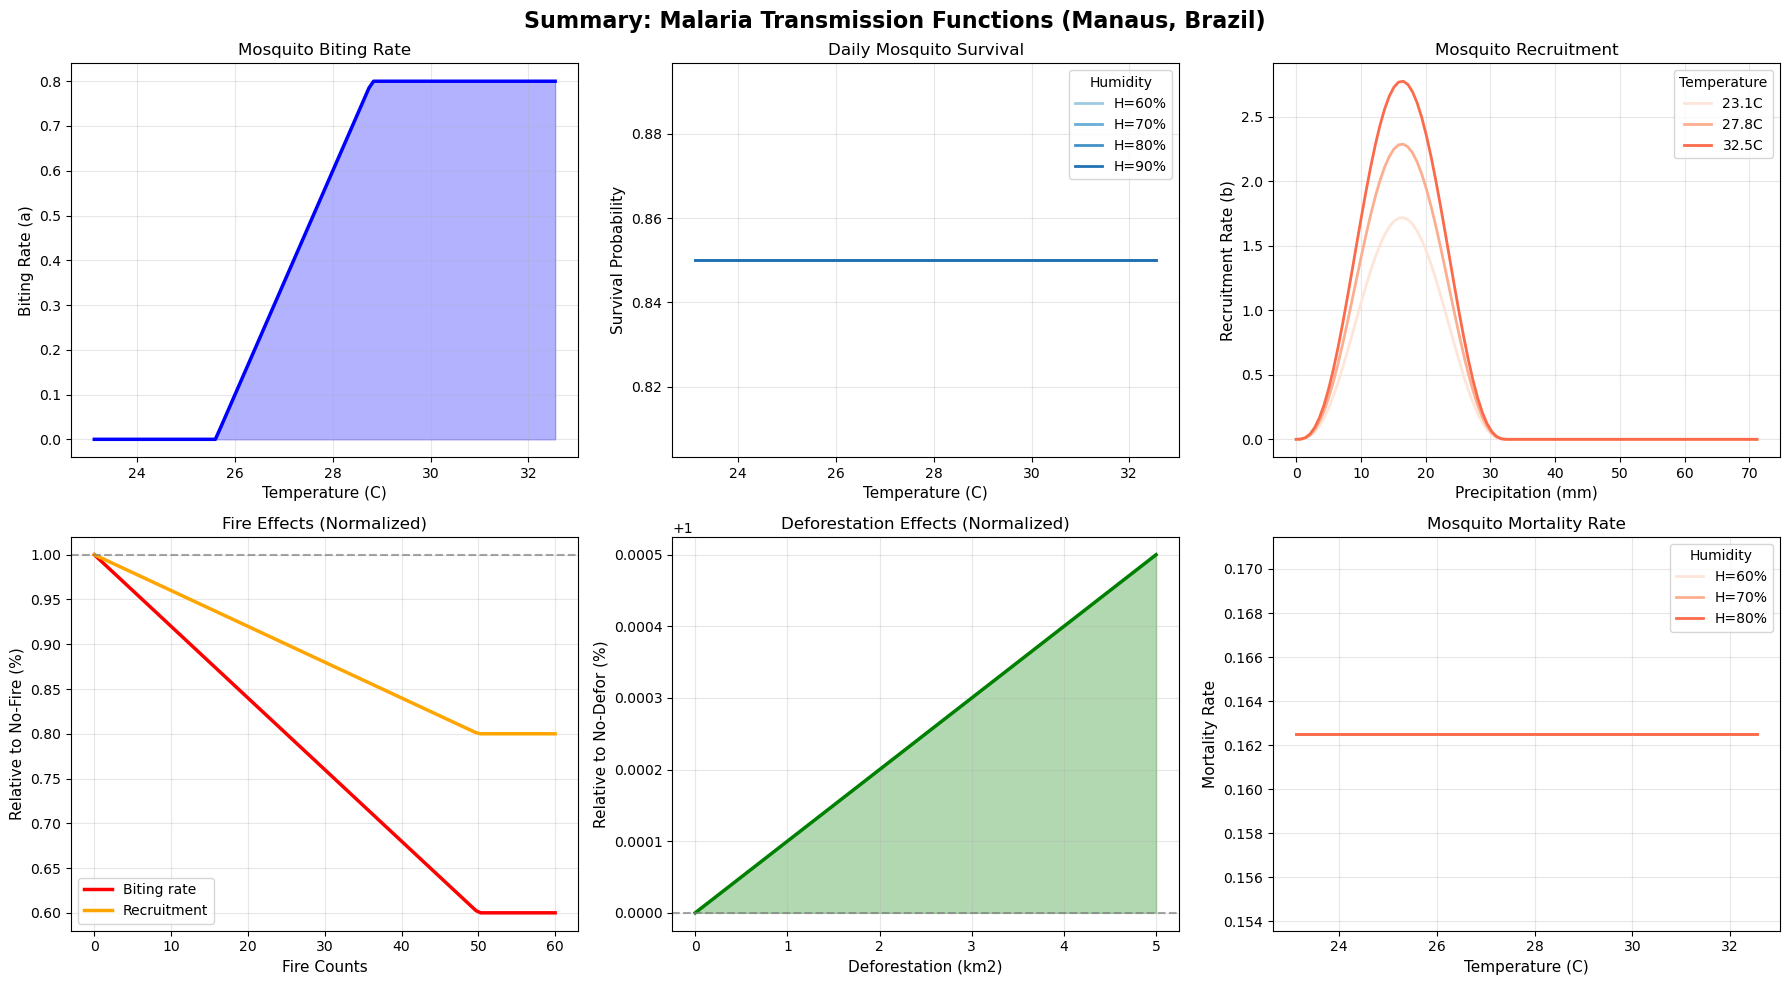


ENVIRONMENTAL FUNCTIONS SUMMARY

TEMPERATURE DEPENDENT:
  - Biting rate (a): Increases with temperature above T_prime=25.6C
  - Larval development (tau_L): Faster at higher temperatures
  - Sporogonic cycle (tau_M): Shorter at higher temperatures
  - Survival (p_T): Optimal around 25-30C
  - Mortality (mu): Increases at temperature extremes

HUMIDITY DEPENDENT:
  - Below 50%: Zero survival
  - 50-60%: Linear increase
  - Above 60%: Full survival

PRECIPITATION DEPENDENT:
  - Egg/Larval/Pupae survival: Peak at R_L/2 mm
  - Recruitment: Optimal around moderate rainfall

DEFORESTATION EFFECTS:
  - Increases breeding sites (puddles)
  - Up to 30% increase in transmission
  - Delayed effect (~14 days)

FIRE EFFECTS:
  - Smoke reduces biting rate (up to 40%)
  - Destroys breeding habitats (up to 20%)
  - Post-fire recovery (~21 days)



In [11]:
# ============================================================================
# PLOT 7: SUMMARY - All Functions with Actual Environmental Ranges
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Summary: Malaria Transmission Functions (Manaus, Brazil)', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 100)
humid_range = np.linspace(max(50, humid_actual.min()), min(100, humid_actual.max()), 100)
rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 100)
fire_range = np.linspace(0, min(60, fire_actual.max()), 100)
defor_range = np.linspace(0, min(5, defor_actual.max()), 100)

# 1. Biting Rate
ax = axes[0, 0]
ax.plot(temp_range, [a(T) for T in temp_range], 'b-', linewidth=2.5)
ax.fill_between(temp_range, 0, [a(T) for T in temp_range], alpha=0.3, color='blue')
ax.set_xlabel('Temperature (C)', fontsize=11)
ax.set_ylabel('Biting Rate (a)', fontsize=11)
ax.set_title('Mosquito Biting Rate', fontsize=12)
ax.grid(True, alpha=0.3)

# 2. Mosquito Survival
ax = axes[0, 1]
humidities = [60, 70, 80, 90]
colors = ['#9ecae1', '#6baed6', '#4292c6', '#2171b5']
for hum, color in zip(humidities, colors):
    ax.plot(temp_range, [p_T(T, hum) for T in temp_range], color=color, linewidth=2, label=f'H={hum}%')
ax.set_xlabel('Temperature (C)', fontsize=11)
ax.set_ylabel('Survival Probability', fontsize=11)
ax.set_title('Daily Mosquito Survival', fontsize=12)
ax.legend(title='Humidity')
ax.grid(True, alpha=0.3)

# 3. Recruitment Rate
ax = axes[0, 2]
temps = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 2 for i in range(3)]
colors = ['#fee5d9', '#fcae91', '#fb6a4a']
for t, c in zip(temps, colors):
    ax.plot(rain_range, [b_rate(R, t, R_L) for R in rain_range], color=c, linewidth=2, label=f'{t:.1f}C')
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Recruitment Rate (b)', fontsize=11)
ax.set_title('Mosquito Recruitment', fontsize=12)
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

# 4. Fire Effects
ax = axes[1, 0]
base_biting = a(temp_actual.mean())
biting_w_fire = [a_with_fire(temp_actual.mean(), f, fire_smoke_effect) for f in fire_range]
base_recruit = b_rate(rain_actual.mean(), temp_actual.mean(), R_L)
recruit_w_fire = [b_rate_with_environment(rain_actual.mean(), temp_actual.mean(), R_L, f, 0) for f in fire_range]
ax.plot(fire_range, [x/base_biting for x in biting_w_fire], 'r-', linewidth=2.5, label='Biting rate')
ax.plot(fire_range, [x/base_recruit for x in recruit_w_fire], 'orange', linewidth=2.5, label='Recruitment')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Fire Counts', fontsize=11)
ax.set_ylabel('Relative to No-Fire (%)', fontsize=11)
ax.set_title('Fire Effects (Normalized)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Deforestation Effects
ax = axes[1, 1]
base_recruit = b_rate(rain_actual.mean(), temp_actual.mean(), R_L)
recruit_w_defor = [b_rate_with_environment(rain_actual.mean(), temp_actual.mean(), R_L, 0, d) for d in defor_range]
ax.plot(defor_range, [x/base_recruit for x in recruit_w_defor], 'g-', linewidth=2.5)
ax.fill_between(defor_range, 1, [x/base_recruit for x in recruit_w_defor], alpha=0.3, color='green')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Deforestation (km2)', fontsize=11)
ax.set_ylabel('Relative to No-Defor (%)', fontsize=11)
ax.set_title('Deforestation Effects (Normalized)', fontsize=12)
ax.grid(True, alpha=0.3)

# 6. Mortality Rate
ax = axes[1, 2]
for hum, color in zip(humidities, colors):
    ax.plot(temp_range, [mu(T, hum) for T in temp_range], color=color, linewidth=2, label=f'H={hum}%')
ax.set_xlabel('Temperature (C)', fontsize=11)
ax.set_ylabel('Mortality Rate', fontsize=11)
ax.set_title('Mosquito Mortality Rate', fontsize=12)
ax.legend(title='Humidity')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('ENVIRONMENTAL FUNCTIONS SUMMARY')
print('='*70)
print('''
TEMPERATURE DEPENDENT:
  - Biting rate (a): Increases with temperature above T_prime=25.6C
  - Larval development (tau_L): Faster at higher temperatures
  - Sporogonic cycle (tau_M): Shorter at higher temperatures
  - Survival (p_T): Optimal around 25-30C
  - Mortality (mu): Increases at temperature extremes

HUMIDITY DEPENDENT:
  - Below 50%: Zero survival
  - 50-60%: Linear increase
  - Above 60%: Full survival

PRECIPITATION DEPENDENT:
  - Egg/Larval/Pupae survival: Peak at R_L/2 mm
  - Recruitment: Optimal around moderate rainfall

DEFORESTATION EFFECTS:
  - Increases breeding sites (puddles)
  - Up to 30% increase in transmission
  - Delayed effect (~14 days)

FIRE EFFECTS:
  - Smoke reduces biting rate (up to 40%)
  - Destroys breeding habitats (up to 20%)
  - Post-fire recovery (~21 days)
''')
print('='*70)


In [12]:
# ============================================================================
# INTERACTIVE 3D SURFACE PLOTS - Using Plotly for rotation/zoom
# ============================================================================
# Note: These plots are interactive - you can rotate, zoom, and pan them!

# Create meshgrid using actual data ranges
temp_3d = np.linspace(temp_actual.min(), temp_actual.max(), 50)
humid_3d = np.linspace(max(50, humid_actual.min()), min(100, humid_actual.max()), 50)
rain_3d = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 50)
fire_3d = np.linspace(0, min(100, fire_actual.max()), 50)
defor_3d = np.linspace(0, min(10, defor_actual.max()), 50)

T, H = np.meshgrid(temp_3d, humid_3d)
T2, R = np.meshgrid(temp_3d, rain_3d)
F, D = np.meshgrid(fire_3d, defor_3d)


In [13]:
# ============================================================================
# PLOT 1: Daily Survival Probability (Temperature x Humidity)
# ============================================================================
Z1 = np.array([[p_T(t, h) for t in temp_3d] for h in humid_3d])

fig1 = go.Figure()
fig1.add_trace(go.Surface(
    x=temp_3d, y=humid_3d, z=Z1,
    colorscale='Blues',
    opacity=0.9,
    colorbar=dict(title='Survival Prob.', len=0.6)
))

fig1.update_layout(
    title=f'Daily Mosquito Survival Probability<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Humidity: {humid_3d.min():.0f}-{humid_3d.max():.0f}% | Rotate/zoom with mouse</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Humidity (%)',
        zaxis_title='Survival Probability',
        zaxis=dict(range=[0, 1])
    ),
    height=600
)

fig1.show()


In [14]:
# ============================================================================
# PLOT 2: Biting Rate (Temperature x Fire)
# ============================================================================
Z2 = np.array([[a_with_fire(t, f, fire_smoke_effect) for t in temp_3d] for f in fire_3d])

fig2 = go.Figure()
fig2.add_trace(go.Surface(
    x=temp_3d, y=fire_3d, z=Z2,
    colorscale='YlOrRd',
    opacity=0.9,
    colorbar=dict(title='Biting Rate', len=0.6)
))

fig2.update_layout(
    title=f'Mosquito Biting Rate<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Fire: {fire_3d.min():.0f}-{fire_3d.max():.0f} | Rotate/zoom with mouse</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Fire Counts',
        zaxis_title='Biting Rate'
    ),
    height=600
)

fig2.show()


In [15]:
# ============================================================================
# PLOT 3: Recruitment Rate (Temperature x Precipitation)
# ============================================================================
Z3 = np.array([[b_rate(r, t, R_L) for t in temp_3d] for r in rain_3d])

fig3 = go.Figure()
fig3.add_trace(go.Surface(
    x=temp_3d, y=rain_3d, z=Z3,
    colorscale='Greens',
    opacity=0.9,
    colorbar=dict(title='Recruitment Rate', len=0.6)
))

fig3.update_layout(
    title=f'Mosquito Recruitment Rate<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Precipitation: {rain_3d.min():.1f}-{rain_3d.max():.1f}mm | Rotate/zoom with mouse</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Precipitation (mm)',
        zaxis_title='Recruitment Rate'
    ),
    height=600
)

fig3.show()


In [16]:
# ============================================================================
# PLOT 4: Recruitment Rate (Fire x Deforestation)
# ============================================================================
temp_f = temp_actual.mean()
rain_f = rain_actual.mean()
Z4 = np.array([[b_rate_with_environment(rain_f, temp_f, R_L, f, d) for f in fire_3d] for d in defor_3d])

fig4 = go.Figure()
fig4.add_trace(go.Surface(
    x=fire_3d, y=defor_3d, z=Z4,
    colorscale='RdYlGn_r',
    opacity=0.9,
    colorbar=dict(title='Recruitment Rate', len=0.6)
))

fig4.update_layout(
    title=f'Recruitment Rate (Fire x Deforestation)<br><sup>Fire: {fire_3d.min():.0f}-{fire_3d.max():.0f} | Defor: {defor_3d.min():.2f}-{defor_3d.max():.2f} km2 | T={temp_f:.1f}C, Rain={rain_f:.1f}mm | Rotate/zoom</sup>',
    scene=dict(
        xaxis_title='Fire Counts',
        yaxis_title='Deforestation (km2)',
        zaxis_title='Recruitment Rate'
    ),
    height=600
)

fig4.show()


In [17]:
# ============================================================================
# PLOT 5: Mortality Rate (Temperature x Humidity)
# ============================================================================
Z_mort = np.array([[mu(t, h) for t in temp_3d] for h in humid_3d])

fig5 = go.Figure()
fig5.add_trace(go.Surface(
    x=temp_3d, y=humid_3d, z=Z_mort,
    colorscale='Hot',
    opacity=0.9,
    colorbar=dict(title='Mortality Rate', len=0.6)
))

fig5.update_layout(
    title=f'Mosquito Mortality Rate<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Humidity: {humid_3d.min():.0f}-{humid_3d.max():.0f}% | Rotate/zoom with mouse</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Humidity (%)',
        zaxis_title='Mortality Rate'
    ),
    height=600
)

fig5.show()


In [18]:
# ============================================================================
# PLOT 6: Transmission Potential Index (Temperature x Humidity)
# ============================================================================
def transmission_potential(T, H, R=20, F=0, D=0):
    biting = a_with_fire(T, F, fire_smoke_effect)
    survival = p_T(T, H)
    recruit = b_rate_with_environment(R, T, R_L, F, D)
    return biting * survival * recruit

Z_trans = np.array([[transmission_potential(t, h) for t in temp_3d] for h in humid_3d])
Z_trans_norm = (Z_trans - Z_trans.min()) / (Z_trans.max() - Z_trans.min())

fig6 = go.Figure()
fig6.add_trace(go.Surface(
    x=temp_3d, y=humid_3d, z=Z_trans_norm,
    colorscale='Viridis',
    opacity=0.9,
    colorbar=dict(title='Relative Risk', len=0.6)
))

fig6.update_layout(
    title=f'Transmission Potential Index<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Humidity: {humid_3d.min():.0f}-{humid_3d.max():.0f}% | Biting x Survival x Recruitment | Rotate/zoom</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Humidity (%)',
        zaxis_title='Normalized Transmission'
    ),
    height=600
)

fig6.show()


In [19]:
# ============================================================================
# PLOT 7: Full Transmission Potential (Temperature x Fire)
# ============================================================================
def trans_potential_full(T, F, H=80, R=20, D=0):
    biting = a_with_fire(T, F, fire_smoke_effect)
    survival = p_T(T, H)
    recruit = b_rate_with_environment(R, T, R_L, F, D)
    return biting * survival * recruit

TV, FV = np.meshgrid(temp_3d, fire_3d)
ZV = np.array([[trans_potential_full(t, f) for t in temp_3d] for f in fire_3d])

fig7 = go.Figure()
fig7.add_trace(go.Surface(
    x=temp_3d, y=fire_3d, z=ZV,
    colorscale='Plasma',
    opacity=0.9,
    colorbar=dict(title='Transmission Potential', len=0.6)
))

fig7.update_layout(
    title=f'Transmission Potential: Temperature x Fire<br><sup>Temperature: {temp_3d.min():.1f}-{temp_3d.max():.1f}C | Fire: {fire_3d.min():.0f}-{fire_3d.max():.0f} | Rotate/zoom with mouse</sup>',
    scene=dict(
        xaxis_title='Temperature (C)',
        yaxis_title='Fire Counts',
        zaxis_title='Transmission Potential'
    ),
    height=600
)

fig7.show()

print('='*70)
print('INTERACTIVE 3D PLOTS - USAGE TIPS')
print('='*70)
print('''
- Click and drag to rotate the plot
- Scroll to zoom in/out
- Right-click and drag to pan
- Hover over the surface to see exact values
- Use the camera controls in the toolbar for preset views
''')
print('='*70)


INTERACTIVE 3D PLOTS - USAGE TIPS

- Click and drag to rotate the plot
- Scroll to zoom in/out
- Right-click and drag to pan
- Hover over the surface to see exact values
- Use the camera controls in the toolbar for preset views

